# T2-1. 타이타닉 Simple Baseline  

생존여부 예측모델 만들기  

학습용 데이터 (X_train, y_train) 을 이용하여 생존 예측 모형을 만든 후, 이를 평가용 데이터 (X_test) 에 적용하여 얻은 예측값을 다음과 같은 형식의 CSV 파일로 생성하시오.   
(가) 제공 데이터 목록
- y_train : 생존여부 (학습용)
- X_traink, X_test : 승객 정보 (학습용 및 평가용)

(나) 데이터 형식 및 내용  
- y_train (712명 데이터)  

유의사항  
- 성능이 우수한 예측모형을 구축하기 위해서는 적절한 데이터 전처리, 피처엔지니어링, 분류알고리즘, 하이퍼파라미터 튜닝, 모형 앙상블 등이 수반되어야한다.  
- 수험번호.csv 파일이 만들어지도록 코드를 제출한다.  
- 제출한 모델의 성능은 accuracy 로 평가함  

In [76]:
import pandas as pd 
import numpy as np 
from sklearn.model_selection import train_test_split 

df = pd.read_csv(r"C:\Users\user\Desktop\GitHub\BigData_Analysis_Exam\Data\Titanic.csv")
display(df.head(5))

def exam_data_load(df, target, id_name ="", null_name = ""):
    # 데이터셋에 식별할 식별자가 없으면 (ID) 판다스가 기본적으로 부여하는 행 인덱스 (0,1,2,3..) 라도 강제로 부여
    if id_name == "":
        df=df.reset_index().rename(columns={"index","id"})
        id_name = 'id'
    else : 
        id_name = id_name 
    # ?,0,NaN 등의 비어있는 칸을 위해서 (통계 연산 불가능)
    # null_index 가 이상하면 정통 결측치 상태인 Nan 으로 치환해버린다.
    if null_name != "":
        df[df==null_name]=np.nan
    
    X_train,X_test = train_test_split(df ,test_size=0.2, random_state=42)

    # 무작위로 쪼개진 학습용 데이터 더이 X_train. 에서 채점에 꼭 필요한 'ID" 열과 '정답열만' 갖다가 쓰겟다.
    y_train = X_train[[id_name, target]]
    X_train = X_train.drop(columns=[target])

    y_test = X_test[[id_name, target]]
    X_test = X_test.drop(columns=[target])
    return X_train,X_test, y_train, y_test 

X_train,X_test, y_train, y_test = exam_data_load(df, target='Survived',id_name='PassengerId')

,PassengerId,Survived,Pclass,Name,Gender,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [77]:
X_train.shape, y_train.shape, X_test.shape

((712, 11), (712, 2), (179, 11))

In [78]:
# EDA
X_train.head()

,PassengerId,Pclass,Name,Gender,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
331,332,1,"Partner, Mr. Austen",male,45.5,0,0,113043,28.5000,C124,S
733,734,2,"Berriman, Mr. William John",male,23.0,0,0,28425,13.0000,NaN,S
382,383,3,"Tikkanen, Mr. Juho",male,32.0,0,0,STON/O 2. 3101293,7.9250,NaN,S
704,705,3,"Hansen, Mr. Henrik Juul",male,26.0,1,0,350025,7.8542,NaN,S
813,814,3,"Andersson, Miss. Ebba Iris Alfrida",female,6.0,4,2,347082,31.2750,NaN,S


In [79]:
X_train.info()

<class 'pandas.DataFrame'>
Index: 712 entries, 331 to 102
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  712 non-null    int64  
 1   Pclass       712 non-null    int64  
 2   Name         712 non-null    str    
 3   Gender       712 non-null    str    
 4   Age          572 non-null    float64
 5   SibSp        712 non-null    int64  
 6   Parch        712 non-null    int64  
 7   Ticket       712 non-null    str    
 8   Fare         712 non-null    float64
 9   Cabin        159 non-null    str    
 10  Embarked     710 non-null    str    
dtypes: float64(2), int64(4), str(5)
memory usage: 66.8 KB


In [80]:
y_train.head()

,PassengerId,Survived
331,332,0
733,734,0
382,383,0
704,705,0
813,814,0


In [81]:
y_train['Survived'].value_counts() # 생존 비율

Survived
0    444
1    268
Name: count, dtype: int64

In [82]:
# 데이터 전처리
y = y_train['Survived']

# sex만 원핫 인코딩 웹
features = ["Pclass","Gender","SibSp","Parch"]
# get_dummies : 데이터 프레임을 통째로 집어넣으면, 
# 내부에 잇는 열 중 object 타입 (문자열) 이나 category 타입의 열만 자동으로 골라내 원-핫 인코딩 수행
# 숫자형 열은 그대로 둔다. 
display(X_train.head(2))
X= pd.get_dummies(X_train[features])
display(X.head())
test = pd.get_dummies(X_test[features])

,PassengerId,Pclass,Name,Gender,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
331,332,1,"Partner, Mr. Austen",male,45.5,0,0,113043,28.5,C124,S
733,734,2,"Berriman, Mr. William John",male,23.0,0,0,28425,13.0,NaN,S


,Pclass,SibSp,Parch,Gender_female,Gender_male
331,1,0,0,False,True
733,2,0,0,False,True
382,3,0,0,False,True
704,3,1,0,False,True
813,3,4,2,True,False


In [83]:
X.shape, test.shape

((712, 5), (179, 5))

In [84]:
# 모델 및 평가
from sklearn.ensemble import RandomForestClassifier 

model1 = RandomForestClassifier(n_estimators=200, max_depth=7, random_state=42)
model1.fit(X,y)
predictions=model1.predict(test)

model1.score(X,y)

0.8230337078651685

In [85]:
# 모델 및 평가
from sklearn.ensemble import RandomForestClassifier 

model2 = RandomForestClassifier(n_estimators=1000, max_depth=7, random_state=42)
model2.fit(X,y)
predictions=model2.predict(test)

model2.score(X,y)

0.824438202247191

In [86]:
# 모델 및 평가
from sklearn.ensemble import RandomForestClassifier 

model3 = RandomForestClassifier(n_estimators=200, max_depth=15, random_state=42)
model3.fit(X,y)
predictions=model3.predict(test)

model3.score(X,y)

0.824438202247191

In [87]:
# 모델 및 평가
from sklearn.ensemble import RandomForestClassifier 

model4 = RandomForestClassifier(n_estimators=200, max_depth=7, random_state=1000)
model4.fit(X,y)
predictions=model4.predict(test)

model4.score(X,y)

0.824438202247191

In [88]:
output = pd.DataFrame({"PassengerId":X_test.PassengerId, "Survived":predictions})
output.head()

,PassengerId,Survived
709,710,0
439,440,0
840,841,0
720,721,1
39,40,0


In [89]:
# 수험번호.csv 로 출력

"""
output.to_csv("123.csv",index=False)

"""

'\noutput.to_csv("123.csv",index=False)\n\n'

In [90]:
# 결과 채점
print(model1.score(test,y_test["Survived"]))
print(model2.score(test,y_test["Survived"]))
print(model3.score(test,y_test["Survived"]))
print(model4.score(test,y_test["Survived"]))

0.7821229050279329
0.7821229050279329
0.7877094972067039
0.7821229050279329


In [91]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier 

# 1. 원-핫 인코딩이 완료된 X 데이터를 학습용(train)과 검증용(val)으로 쪼갭니다.
X_tr, X_val, y_tr, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. 모델 선언 및 학습 (학습용 데이터만 사용!)
model = RandomForestClassifier(n_estimators=200, max_depth=7, random_state=42)
model.fit(X_tr, y_tr)

# 3. 🔥 성능 평가는 반드시 검증용 데이터(X_val, y_val)로 확인!
print("훈련 데이터 점수:", model.score(X_tr, y_tr))
print("검증 데이터 점수:", model.score(X_val, y_val))

훈련 데이터 점수: 0.8312829525483304
검증 데이터 점수: 0.7902097902097902


# T2-2 Pima Indians Diabetes (피아 인디언 당뇨병)  

당뇨병 여부 판단  
예측 컬럼 : Outcome (0 정상, 1 당뇨) 당뇨병일 확률 예측  
평가지표 : roc-auc  
제출파일명 : result.csv(1개 컬럼, 컬럼명 pred)  

In [92]:
import pandas as pd 
import os 
from sklearn.model_selection import train_test_split  

train = pd.read_csv(r"C:\Users\user\Desktop\GitHub\BigData_Analysis_Exam\Data\diabetes_train.csv")
test = pd.read_csv(r"C:\Users\user\Desktop\GitHub\BigData_Analysis_Exam\Data\diabetes_test.csv")
display(train.head(2))
display(test.head(2))


,id,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,377,1,87,60,37,75,37.2,0.509,22,0
1,370,3,173,82,48,465,38.4,2.137,25,1


,id,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,258,1,193,50,16,375,25.9,0.655,24
1,220,0,177,60,29,478,34.6,1.072,21


In [93]:
train['Outcome'].value_counts()

Outcome
0    381
1    195
Name: count, dtype: int64

In [94]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 576 entries, 0 to 575
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   id                        576 non-null    int64  
 1   Pregnancies               576 non-null    int64  
 2   Glucose                   576 non-null    int64  
 3   BloodPressure             576 non-null    int64  
 4   SkinThickness             576 non-null    int64  
 5   Insulin                   576 non-null    int64  
 6   BMI                       576 non-null    float64
 7   DiabetesPedigreeFunction  576 non-null    float64
 8   Age                       576 non-null    int64  
 9   Outcome                   576 non-null    int64  
dtypes: float64(2), int64(8)
memory usage: 45.1 KB


In [95]:
train.isnull().sum()

id                          0
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [96]:
# 데이터 전처리
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
cols = ["Pregnancies","Glucose","BloodPressure","SkinThickness","Insulin","BMI","DiabetesPedigreeFunction","Age"]
train[cols] = scaler.fit_transform(train[cols])
test[cols] = scaler.fit_transform(test[cols])

'''
StandardScaler : 서로 다른 척도 (단위) 를 가진 데이터들의 체급을 똑같이 맞춰주는 도구
데이터의 평균을 0, 표준편차를 1이 되도록 변환하여 정규분포 모양으로 표준화하는 역할을 한다.  
ex) 인슐린 숫자는 몇백단위로 요동치는데 당뇨 내력 가중치는 1 안팍에서 놀아 변수의 가중치가 조정되는 것을 고치기 위함.
'''

'\nStandardScaler : 서로 다른 척도 (단위) 를 가진 데이터들의 체급을 똑같이 맞춰주는 도구\n데이터의 평균을 0, 표준편차를 1이 되도록 변환하여 정규분포 모양으로 표준화하는 역할을 한다.  \nex) 인슐린 숫자는 몇백단위로 요동치는데 당뇨 내력 가중치는 1 안팍에서 놀아 변수의 가중치가 조정되는 것을 고치기 위함.\n'

In [97]:
# id 제외
display(train.head(2))
train = train.drop('id',axis=1)
test = test.drop('id',axis=1)
display(train.head(2))

,id,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,377,-0.846722,-1.037009,-0.419767,1.000802,-0.061847,0.687444,0.086445,-0.949139,0
1,370,-0.255914,1.651637,0.676768,1.691778,3.319349,0.841447,4.828849,-0.698357,1


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,-0.846722,-1.037009,-0.419767,1.000802,-0.061847,0.687444,0.086445,-0.949139,0
1,-0.255914,1.651637,0.676768,1.691778,3.319349,0.841447,4.828849,-0.698357,1


In [98]:
target = train.pop("Outcome")
display(target)

0      0
1      1
2      1
3      1
4      1
      ..
571    0
572    1
573    0
574    0
575    1
Name: Outcome, Length: 576, dtype: int64

In [99]:
# 학습 및 예측
from sklearn.ensemble import RandomForestClassifier 

model = RandomForestClassifier(random_state=42)
model.fit(train,target)
predictions = model.predict_proba(test)
display(predictions)
# 당뇨 확률값 선택
pred = predictions[:,1]

array([[0.39, 0.61],
       [0.28, 0.72],
       [1.  , 0.  ],
       [0.15, 0.85],
       [0.68, 0.32],
       [0.78, 0.22],
       [0.3 , 0.7 ],
       [0.98, 0.02],
       [0.71, 0.29],
       [0.71, 0.29],
       [0.57, 0.43],
       [0.91, 0.09],
       [0.95, 0.05],
       [0.4 , 0.6 ],
       [0.97, 0.03],
       [0.54, 0.46],
       [0.76, 0.24],
       [0.35, 0.65],
       [0.46, 0.54],
       [0.44, 0.56],
       [0.78, 0.22],
       [0.19, 0.81],
       [0.97, 0.03],
       [0.23, 0.77],
       [0.6 , 0.4 ],
       [0.77, 0.23],
       [0.28, 0.72],
       [0.9 , 0.1 ],
       [0.71, 0.29],
       [0.25, 0.75],
       [0.71, 0.29],
       [0.79, 0.21],
       [0.25, 0.75],
       [0.98, 0.02],
       [0.89, 0.11],
       [0.77, 0.23],
       [0.97, 0.03],
       [0.98, 0.02],
       [0.93, 0.07],
       [0.58, 0.42],
       [0.64, 0.36],
       [0.89, 0.11],
       [0.54, 0.46],
       [0.69, 0.31],
       [0.88, 0.12],
       [0.8 , 0.2 ],
       [0.78, 0.22],
       [0.95,

In [100]:
output = pd.DataFrame({'pred':pred})
output.head()

,pred
0,0.61
1,0.72
2,0.00
3,0.85
4,0.32


# T2-3. Adult Census Income Tutorial  
성인 인구조사 소득 예측 
- age(나이), workclass (고용 형태), fnlwgt (사람의 대표성을 나타내는 가중치, final weight), education (교육 수준), education.num (교육 수준 수치), marital.status (결혼 상태), occupation (업종), relationship (가족 관계), race (인종), sex (성별), capital.gain (양도 소득), capital.loss (양도 손실), hours.per.week (주당 근무 시간), native.country (국적), income (수익, 예측해야하는 값)

In [101]:
import pandas as pd 
from sklearn.model_selection import train_test_split 

df = pd.read_csv(r"C:\Users\user\Desktop\GitHub\BigData_Analysis_Exam\Data\adult.csv")
display(df.head(2))

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K


In [102]:
# 시험환경 세팅 
def exam_data_load(df, target, id_name="", null_name=""):
    if id_name == "":
        df = df.reset_index().rename(columns={"index": "id"})
        id_name = 'id'
    else:
        id_name = id_name
    
    if null_name != "":
        df[df == null_name] = np.nan
    
    X_train, X_test = train_test_split(df, test_size=0.2, random_state=2021)
    
    y_train = X_train[[id_name, target]]
    X_train = X_train.drop(columns=[target])

    
    y_test = X_test[[id_name, target]]
    X_test = X_test.drop(columns=[target])
    return X_train, X_test, y_train, y_test 

In [103]:
X_train, X_test, y_train, y_test = exam_data_load(df,target='income',null_name="?")
display(X_train.head(2))
display(X_test.head(2))
display(y_train.head(2))
display(y_test.head(2))

,id,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country
21851,21851,36,Private,241998,Bachelors,13,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,50,United-States
7632,7632,53,Private,103950,Masters,14,Divorced,Prof-specialty,Not-in-family,White,Female,0,0,40,United-States


,id,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country
20901,20901,58,Private,114495,HS-grad,9,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,40,United-States
14170,14170,46,Private,247043,HS-grad,9,Married-civ-spouse,Transport-moving,Husband,White,Male,0,0,40,United-States


,id,income
21851,21851,>50K
7632,7632,<=50K


,id,income
20901,20901,<=50K
14170,14170,>50K


In [104]:
# EDA
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)
display(X_train.head(2))

(26048, 15) (6513, 15) (26048, 2) (6513, 2)


,id,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country
21851,21851,36,Private,241998,Bachelors,13,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,50,United-States
7632,7632,53,Private,103950,Masters,14,Divorced,Prof-specialty,Not-in-family,White,Female,0,0,40,United-States


In [105]:
print(y_train['income'].value_counts())

income
<=50K    19756
>50K      6292
Name: count, dtype: int64


In [106]:
print(X_train.isnull().sum())

id                   0
age                  0
workclass         1456
fnlwgt               0
education            0
education.num        0
marital.status       0
occupation        1463
relationship         0
race                 0
sex                  0
capital.gain         0
capital.loss         0
hours.per.week       0
native.country     461
dtype: int64


In [107]:
print(X_test.isnull().sum())

id                  0
age                 0
workclass         380
fnlwgt              0
education           0
education.num       0
marital.status      0
occupation        380
relationship        0
race                0
sex                 0
capital.gain        0
capital.loss        0
hours.per.week      0
native.country    122
dtype: int64


In [108]:
numeric_features = ["age","fnlwgt","education.num","capital.gain","capital.loss","hours.per.week"]
str_features = ["workclass","education","marital.status","occupation","relationship","race","sex","native.country"]

print(X_train.isnull().sum())
# 결측치 처리 (최빈값과 차이가 크면 최빈값으로 값이 비슷하면 별도의 값으로)
def data_fillna(df) : 
    df['workclass'] = df['workclass'].fillna(df['workclass'].mode()[0])
    df['occupation'] = df['occupation'].fillna("null")
    df["native.country"] = df["native.country"].fillna(df["native.country"].mode()[0])
    return df

X_train = data_fillna(X_train)
X_test = data_fillna(X_test)

id                   0
age                  0
workclass         1456
fnlwgt               0
education            0
education.num        0
marital.status       0
occupation        1463
relationship         0
race                 0
sex                  0
capital.gain         0
capital.loss         0
hours.per.week       0
native.country     461
dtype: int64


In [109]:
print(X_train.isnull().sum())

id                0
age               0
workclass         0
fnlwgt            0
education         0
education.num     0
marital.status    0
occupation        0
relationship      0
race              0
sex               0
capital.gain      0
capital.loss      0
hours.per.week    0
native.country    0
dtype: int64


In [110]:
# 피쳐 엔지니어링
from sklearn.preprocessing import LabelEncoder 

all_df = pd.concat([X_train.assign(ind="train"),X_test.assign(ind="test")])
# assign : 기존 데이터 프레임의 원본은 건드리지 않고, 새로운 열을 임시로 덧붙여서 복사본을 반환하는 함수 
# X_train.assign(ind="train") : X_train 데이터프레임의 가장 오른쪽에 ind 라는 이름의 새로운 열을 만들고, 모든 행의 값을 "trian" 이라는 문자열로 채워라

le = LabelEncoder()
# LabelEncoder : 알파벳이나 한글로 된 문자형 범주 데이터(Object) 를 0부터 시작하는 순차적인 정수 (Integer) 로 일대일 매핑해주는 도구
# ML model 은 문자를 알아듣지 못하므로 LabelEncoder 로 숫자 부여해줌 
all_df[str_features] = all_df[str_features].apply(le.fit_transform)

X_train = all_df[all_df['ind']=="train"]
X_train = X_train.drop('ind',axis=1)
# 임시 마커 제거
display(X_train)

X_test= all_df[all_df['ind']=="test"]
X_test = X_test.drop('ind',axis=1)
display(X_test)

,id,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country
21851,21851,36,3,241998,9,13,2,2,0,4,1,0,0,50,38
7632,7632,53,3,103950,12,14,0,9,1,4,0,0,0,40,38
27878,27878,19,3,203061,15,10,4,12,1,4,0,0,0,25,38
14121,14121,20,3,102607,11,9,4,5,3,4,1,0,0,30,38
32345,32345,54,6,138852,11,9,2,9,0,4,1,0,0,40,38
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2669,2669,45,3,187370,12,14,0,3,4,4,1,7430,0,70,38
17536,17536,36,3,174308,1,7,0,13,1,4,1,0,0,40,38
6201,6201,47,3,275361,7,12,6,7,3,4,0,0,0,35,38
27989,27989,50,5,196504,10,16,2,9,0,4,1,0,0,23,38


,id,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country
20901,20901,58,3,114495,11,9,2,3,0,4,1,0,0,40,38
14170,14170,46,3,247043,11,9,2,13,0,4,1,0,0,40,38
1776,1776,67,1,103315,12,14,4,3,2,4,0,15831,0,72,38
30428,30428,18,3,165532,15,10,4,11,3,4,1,0,0,15,38
8602,8602,26,6,58039,15,10,2,7,0,4,1,0,0,40,38
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31222,31222,22,3,199426,15,10,4,14,1,4,0,0,0,40,38
10861,10861,41,3,155106,11,9,2,5,0,4,1,0,0,40,38
8929,8929,32,3,153078,9,13,4,7,1,1,1,0,0,40,34
2066,2066,48,6,171926,14,15,2,9,0,4,1,15024,0,50,38


In [111]:
# 스케일링
from sklearn.preprocessing import MinMaxScaler 

scaler = MinMaxScaler()
X_train[numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_test[numeric_features] = scaler.fit_transform(X_test[numeric_features])
display(X_train.head(2))

,id,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country
21851,21851,0.260274,3,0.156011,9,0.800000,2,2,0,4,1,0.0,0.0,0.500000,38
7632,7632,0.493151,3,0.062255,12,0.866667,0,9,1,4,0,0.0,0.0,0.397959,38


In [112]:
y = (y_train['income'] != "<=50K").astype(int)
y[:5]

21851    1
7632     0
27878    0
14121    0
32345    0
Name: income, dtype: int64

In [113]:
# 검증용 데이터 분리
from sklearn.model_selection import train_test_split 
X_tr, X_val, y_tr, y_val = train_test_split(X_train, y, test_size=0.15, random_state=42)
display(X_tr.head(2))

,id,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country
12462,12462,0.136986,3,0.017192,15,0.600000,4,7,1,4,1,0.0,0.0,0.234694,38
15837,15837,0.287671,3,0.112052,11,0.533333,2,14,5,4,0,0.0,0.0,0.346939,38


In [114]:
X_tr = X_tr.drop('id',axis=1)
X_val = X_val.drop('id',axis=1)

In [115]:
# 모델 & 평가
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

model = DecisionTreeClassifier(random_state=42)
model.fit(X_tr,y_tr)
pred= model.predict(X_val)
print("accuracy score : ",(accuracy_score(y_val, pred)))

accuracy score :  0.8011770726714432


In [116]:
# 랜덤 포레스트
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(random_state = 42)
model.fit(X_tr,y_tr)
pred = model.predict(X_val)
print("accuracy score : ",(accuracy_score(y_val, pred)))

accuracy score :  0.848259979529171


In [117]:
# test 데이터 예측
X_test_id = X_test.pop('id')
pred = model.predict(X_test)

In [118]:
output = pd.DataFrame({'id':X_test_id, 'income' : pred})
output.head(5)

,id,income
20901,20901,1
14170,14170,0
1776,1776,1
30428,30428,0
8602,8602,0


In [119]:
# 채점
y_test = (y_test['income'] != '<=50K').astype(int)
from sklearn.metrics import accuracy_score 
print("accuracy score : ",(accuracy_score(y_test,pred)))

accuracy score :  0.8453861507753724


# Scaler 사용 
1. 데이터에 튀는 값 (이상치) 가 눈에 띄게 많거나 분포가 종 모양 (정규분포) 에 가까우면 => StandardScaler
2. 데이터의 상한/ 하한이 확실하고 (나이, 시험 점수), 이상치가 거의 없다면 => MinMaxScaler 
3. 어떤 스케일러를 써야할 지 감이 안잡히는 애매한 데이터셋 => StandardScaler 
4. 이상치가 많거나 대체하기 힘든 금융 데이터 => RobustScaler (중앙값과 IQR 기반 스케일링)
5. 데이터 세트에 0이 엄청나게 많이 채워져 있는 희소 행렬 구조이면 => MaxAbsScaler (절대값 기반 스케일러. 절댓값중 최댓값이 무조건 1)
6. 데이터가 무조건 정규분포를 따라야하는 선형 회귀나 로지스틱 회귀등이면 => PowerTransformer (분포 변형 스케일러. Skeness 를 완화시켜 강제로 예쁜 가우시안 정규분포를 만듦)

# Machine Learning
1. 랜덤 포레스트 (앙상블 - 배깅 계열) : 분류 / 회귀
2. 그레디언트 부스팅 (앙상블 - 부스팅 계열) : 분류, 회귀
3. 로지스틱 회귀 / 선형 회귀 : 분류, 회귀
4. 서포트 벡터 머신 (SVM) : 분류, 회귀

In [120]:
# 랜덤 포레스트
from sklearn.ensemble import RandomForestClassifier 
from sklearn.ensemble import RandomForestRegressor

# 그래디언트 부스팅
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import GradientBoostingRegressor

# 로지스틱 회귀 (분류)
from sklearn.linear_model import LogisticRegression
# 선형 회귀 (회귀)
from sklearn.linear_model import LinearRegression 

# 서포트벡터머신
# 시험에서는 쓰지 않기. coputational cost 딸림. 
from sklearn.svm import SVC # 분류
from sklearn.svm import SVR # 회귀

# 문제 평가 지표
1. 분류 : 모델이 예측한 범주나 그 확률이 실제 정답과 얼마나 일치하는지 
    - roc_auc_score
    - f1_score : 정밀도와 재현율의 조화 평균. 데이터 클래스 비율이 깨져있을 때
    - accuracy_score : 전체 중 맞춘 비율. 데이터 불균형이 심하면 왜곡됨
2. 회귀 : 실제 정답선과 모델 예측선 사이의 물리적 거리 (오차) 계산
    - r2_score (결정계수) : 데이터 분산. 1에 가까울수록 완벽한 모델
    - MSE/ RMSE : 오차 (잔차)/ RMSE 루트 씌운거

In [121]:
from sklearn.metrics import roc_auc_score
# predict_proba() 결과 중 1에 해당하는 [:, 1] 확률을 넣어주는 것이 핵심!
pred_proba = model.predict_proba(X_test)[:, 1]
print("ROC-AUC 점수:", roc_auc_score(y_test, pred_proba))

ROC-AUC 점수: 0.8959959090864165


In [122]:
from sklearn.metrics import accuracy_score, f1_score
pred = model.predict(X_test) # 확률이 아니라 0 또는 1 정답 부류를 넣음

print("정확도:", accuracy_score(y_test, pred))
print("F1 점수:", f1_score(y_test, pred)) # 이진 분류 기준

정확도: 0.8453861507753724
F1 점수: 0.6465426465426466


In [123]:
from sklearn.metrics import r2_score
pred = model.predict(X_test)
print("R2 점수:", r2_score(y_test, pred))

R2 점수: 0.14704256703786978


In [124]:
import numpy as np
from sklearn.metrics import mean_squared_error

pred = model.predict(X_test)
mse = mean_squared_error(y_test, pred)
rmse = np.sqrt(mse) # 또는 mean_squared_error(y_test, pred, squared=False)

print("MSE 오차:", mse)
print("RMSE 오차:", rmse)

MSE 오차: 0.15461384922462768
RMSE 오차: 0.3932096759041258


# T2-4. House Price

예측할 변수 ['SalePrice']  
평가 : rmse, r2 (rmse 는 낮을수록, r2는 높을수록 좋은 성능)

In [125]:
# 세팅
import pandas as pd
import numpy as np 
from sklearn.model_selection import train_test_split  

def exam_data_load(df, target, id_name="", null_name=""):
    if id_name == "":
        df = df.reset_index().rename(columns={"index": "id"})
        id_name = 'id'
    else:
        id_name = id_name
    
    if null_name != "":
        df[df == null_name] = np.nan
    
    X_train, X_test = train_test_split(df, test_size=0.2, shuffle=True, random_state=2021)
    y_train = X_train[[id_name, target]]
    X_train = X_train.drop(columns=[id_name, target])
    y_test = X_test[[id_name, target]]
    X_test = X_test.drop(columns=[id_name, target])
    return X_train, X_test, y_train, y_test 

train = pd.read_csv(r"C:\Users\user\Desktop\GitHub\BigData_Analysis_Exam\Data\House_price_train.csv")
test = pd.read_csv(r"C:\Users\user\Desktop\GitHub\BigData_Analysis_Exam\Data\House_price_test.csv")

In [126]:
# EDA
display(train.head(2))
print(train.shape,test.shape)
#print(train.isnull().sum())

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500


(1460, 81) (1459, 80)


In [127]:
pd.set_option('display.max_rows',100)
print(train.isnull().sum())
print(type(train.isnull().sum()))



Id                  0
MSSubClass          0
MSZoning            0
LotFrontage       259
LotArea             0
Street              0
Alley            1369
LotShape            0
LandContour         0
Utilities           0
LotConfig           0
LandSlope           0
Neighborhood        0
Condition1          0
Condition2          0
BldgType            0
HouseStyle          0
OverallQual         0
OverallCond         0
YearBuilt           0
YearRemodAdd        0
RoofStyle           0
RoofMatl            0
Exterior1st         0
Exterior2nd         0
MasVnrType        872
MasVnrArea          8
ExterQual           0
ExterCond           0
Foundation          0
BsmtQual           37
BsmtCond           37
BsmtExposure       38
BsmtFinType1       37
BsmtFinSF1          0
BsmtFinType2       38
BsmtFinSF2          0
BsmtUnfSF           0
TotalBsmtSF         0
Heating             0
HeatingQC           0
CentralAir          0
Electrical          1
1stFlrSF            0
2ndFlrSF            0
LowQualFin

In [128]:
null_counts = train.isnull().sum()
print(null_counts[null_counts>0])

LotFrontage      259
Alley           1369
MasVnrType       872
MasVnrArea         8
BsmtQual          37
BsmtCond          37
BsmtExposure      38
BsmtFinType1      37
BsmtFinType2      38
Electrical         1
FireplaceQu      690
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
PoolQC          1453
Fence           1179
MiscFeature     1406
dtype: int64


In [129]:
X_train, X_test, y_train, y_test = exam_data_load(df, target='SalePrice', id_name='Id')
X_train.shape,y_train.shape,X_test.shape,y_test.shape

KeyError: "None of [Index(['Id', 'SalePrice'], dtype='str')] are in the [columns]"

(array([148., 723., 373., 135.,  51.,  19.,   4.,   3.,   2.,   2.]),
 array([ 34900., 106910., 178920., 250930., 322940., 394950., 466960.,
        538970., 610980., 682990., 755000.]),
 <BarContainer object of 10 artists>)

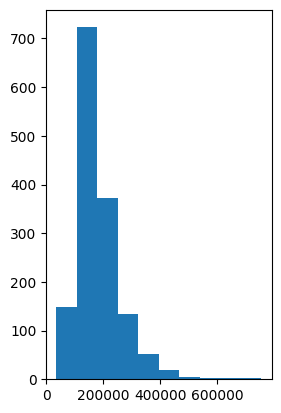

In [ ]:
import matplotlib.pyplot as plt 

plt.subplot(1,2,1)
plt.hist(train['SalePrice'])

#plt.subplot(1,2,2)
#plt.hist(test['SalePrice'])

## T2-5 Insurance Starter 

In [130]:
import pandas as pd 

df = pd.read_csv(r"C:\Users\user\Desktop\GitHub\BigData_Analysis_Exam\Data\insurance.csv")
display(df.head(5))

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [131]:
# 시험 환경 세팅
import pandas as pd
import numpy as np 
from sklearn.model_selection import train_test_split

def exam_data_load(df, target, id_name="",null_name=""):
    if id_name=="":
        df = df.reset_index().rename(columns={"index":"id"})
        id_name="id"
    else:
        id_name=id_name
    if null_name != "":
        df[df==null_name]=np.nan
    
    X_train,X_test = train_test_split(df,test_size=0.2, random_state=42)

    y_train=X_train[[id_name,target]]
    X_train = X_train.drop(columns=[target])

    y_test = X_test[[id_name,target]]
    X_test = X_test.drop(columns=[target])

    return X_train,X_test, y_train, y_test

X_train, X_test, y_train, y_test = exam_data_load(df,target='charges')
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((1070, 7), (268, 7), (1070, 2), (268, 2))

In [132]:
# EDA
X_train.head()

,id,age,sex,bmi,children,smoker,region
560,560,46,female,19.95,2,no,northwest
1285,1285,47,female,24.32,0,no,northeast
1142,1142,52,female,24.86,0,no,southeast
969,969,39,female,34.32,5,no,southeast
486,486,54,female,21.47,3,no,northwest


In [133]:
y_train.head()

,id,charges
560,560,9193.83850
1285,1285,8534.67180
1142,1142,27117.99378
969,969,8596.82780
486,486,12475.35130


<Axes: >

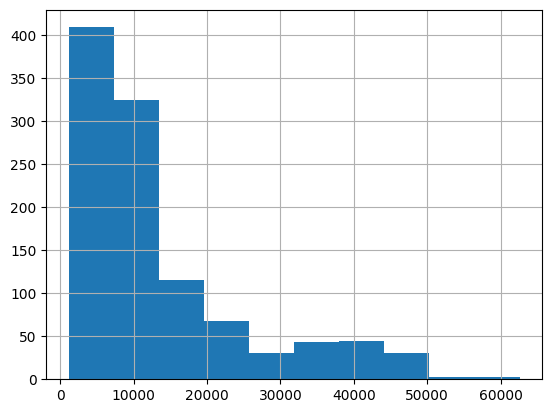

In [134]:
y_train['charges'].hist()

In [135]:
X_train.isnull().sum()

id          0
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
dtype: int64

In [136]:
X_test.isnull().sum()

id          0
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
dtype: int64

In [137]:
X_train.info()

<class 'pandas.DataFrame'>
Index: 1070 entries, 560 to 1126
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        1070 non-null   int64  
 1   age       1070 non-null   int64  
 2   sex       1070 non-null   str    
 3   bmi       1070 non-null   float64
 4   children  1070 non-null   int64  
 5   smoker    1070 non-null   str    
 6   region    1070 non-null   str    
dtypes: float64(1), int64(3), str(3)
memory usage: 66.9 KB


In [138]:
X_train.select_dtypes("object").columns

C:\Users\user\AppData\Local\Temp\ipykernel_20240\3623698985.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  X_train.select_dtypes("object").columns


Index(['sex', 'smoker', 'region'], dtype='str')

In [139]:
cols = X_train.select_dtypes("object").columns

for col in cols:
    print("\n====",col,"====")
    print("[train]")
    print(X_train[col].value_counts())
    print("[test]")
    print(X_test[col].value_counts())


==== sex ====
[train]
sex
male      548
female    522
Name: count, dtype: int64
[test]
sex
female    140
male      128
Name: count, dtype: int64

==== smoker ====
[train]
smoker
no     850
yes    220
Name: count, dtype: int64
[test]
smoker
no     214
yes     54
Name: count, dtype: int64

==== region ====
[train]
region
southeast    283
northeast    267
southwest    264
northwest    256
Name: count, dtype: int64
[test]
region
southeast    81
northwest    69
southwest    61
northeast    57
Name: count, dtype: int64


C:\Users\user\AppData\Local\Temp\ipykernel_20240\3035049483.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cols = X_train.select_dtypes("object").columns


In [140]:
# Preprocessing
cols = X_train.select_dtypes("object").columns

X_train = pd.get_dummies(X_train, columns = cols)
X_test = pd.get_dummies(X_test, columns = cols)

X_train.head(2)

C:\Users\user\AppData\Local\Temp\ipykernel_20240\1518523740.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cols = X_train.select_dtypes("object").columns


,id,age,bmi,children,sex_female,sex_male,smoker_no,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest
560,560,46,19.95,2,True,False,True,False,False,True,False,False
1285,1285,47,24.32,0,True,False,True,False,True,False,False,False


<Axes: >

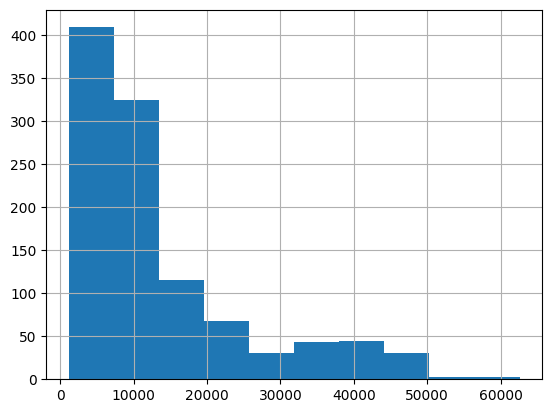

In [141]:
# Log Transform
y_train['charges'].hist()

<Axes: >

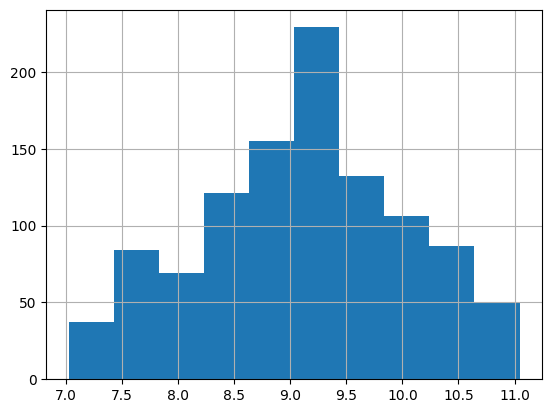

In [142]:
y_train['charges'] = np.log1p(y_train['charges'])
y_train['charges'].hist()

In [143]:
display(X_train['bmi'])
display(X_train[['bmi']])

560     19.950
1285    24.320
1142    24.860
969     34.320
486     21.470
         ...  
1095    31.350
1130    23.870
1294    25.175
860     47.600
1126    29.900
Name: bmi, Length: 1070, dtype: float64

,bmi
560,19.950
1285,24.320
1142,24.860
969,34.320
486,21.470
...,...
1095,31.350
1130,23.870
1294,25.175
860,47.600


In [144]:
# Standard Scaler
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train['bmi']=scaler.fit_transform(X_train[['bmi']])
X_test['bmi']=scaler.fit_transform(X_test[['bmi']])

In [145]:
# label encoding
# 나이를 10대, 20대, 30대로 구분하기 위해 10을 나눈 몫 값만 구함
X_train['age'] = X_train['age'].apply(lambda x : x//10)
X_test['age'] = X_test['age'].apply(lambda x : x//10)

X_train.head(5)

,id,age,bmi,children,sex_female,sex_male,smoker_no,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest
560,560,4,-1.756525,2,True,False,True,False,False,True,False,False
1285,1285,4,-1.033082,0,True,False,True,False,True,False,False,False
1142,1142,5,-0.943687,0,True,False,True,False,False,False,True,False
969,969,3,0.622393,5,True,False,True,False,False,False,True,False
486,486,5,-1.504893,3,True,False,True,False,False,True,False,False


In [148]:
# Train-Validation Split
target = y_train['charges']
X_train = X_train.drop('id', axis=1)

In [149]:
from sklearn.model_selection import train_test_split 

X_tr, X_val, y_tr, y_val = train_test_split(X_train, target, test_size=0.15, random_state=42)
X_tr.shape, X_val.shape, y_tr.shape, y_val.shape

((909, 11), (161, 11), (909,), (161,))

In [150]:
from sklearn.ensemble import RandomForestRegressor 

rf = RandomForestRegressor()
rf.fit(X_tr, y_tr)
pred = rf.predict(X_val)

In [151]:
from sklearn.metrics import mean_squared_error
def rmse2(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))
rmse2(y_val, pred)

np.float64(0.4460816829310664)

In [154]:
from xgboost import XGBRegressor

xgb = XGBRegressor()
xgb.fit(X_tr, y_tr)
pred = xgb.predict(X_val)

In [155]:
rmse2(y_val, pred)

np.float64(0.4951912711250578)

In [156]:
rf.fit(X_train, y_train['charges'])
pred = rf.predict(X_test.drop('id',axis=1))

In [157]:
pred = np.exp(pred)
output = pd.DataFrame({'id':y_test['id'],'charges':pred})
output.head()

,id,charges
764,764,8592.035818
887,887,4682.088386
890,890,27285.006597
1293,1293,8964.444789
259,259,34349.039849


# XGBoost(eXtreme Gradient Boosting) 
- 트리 기반의 앙상블 알고리즘  
- XGBRegressor 는 연속적인 수치를 예측하기 위한 회귀 모델
- 근간이 되는 알고리즘은 Gradient Boosting Machine (GBM) 

- Bagging
    - 여러 트리를 동시에 학습시켜 평균을 냄
- Boosting
    - 트리를 순차적으로 만들며 앞선 트리의 실수를 다음 트리가 점진적으로 고쳐나가는 방법
    - 모델이 예측을 진행할 때마다 손실 함수 (Loss function) 의 기울기 (Gradient, 1차 미분값) 와 헤시안 (Hessian, 2차 미분값) 을 계산하여 오차가 가장 빠르게 줄어드는 방향 (Gradient Descent) 으로 다음 트리를 최적화 함.

- 기존 부스팅 알고리즘 (GBM) 의 치명적인 단점인 느린 연산 속도와 과적합 취약성을 극복한 모델. 
    - 정규화 (Regularization) 포함 : 수식 자체에 모델의 복잡도 (트리의 깊이, 리프 노드의 갯수) 를 억제하는 페널티 항 ($L_1$, $L_2$ 정규화) 가 내장되있음.
    - 병렬 및 분산 연산 (eXtreme) : CPU 의 모든 코어를 활용해 데이터를 정렬하고 트리 분기점을 탐색하므로 학습속도가 극도로 빠름



# T2-6 Bike Regressor  

target : count 컬럼

In [177]:
import numpy as np 
import pandas as pd 
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import RandomForestClassifier

test = pd.read_csv(r"C:\Users\user\Desktop\GitHub\BigData_Analysis_Exam\Data\bike_test.csv")
train = pd.read_csv(r"C:\Users\user\Desktop\GitHub\BigData_Analysis_Exam\Data\bike_train.csv")

### EDA

In [178]:
display(train.head(2))
display(test.head(2))

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40


,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed
0,2011-01-20 00:00:00,1,0,1,1,10.66,11.365,56,26.0027
1,2011-01-20 01:00:00,1,0,1,1,10.66,13.635,56,0.0000


In [179]:
print(train.info())

<class 'pandas.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  str    
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), str(1)
memory usage: 1020.7 KB
None


In [180]:
print(train.isnull().sum())

datetime      0
season        0
holiday       0
workingday    0
weather       0
temp          0
atemp         0
humidity      0
windspeed     0
casual        0
registered    0
count         0
dtype: int64


In [164]:
print(test.isnull().sum())

datetime      0
season        0
holiday       0
workingday    0
weather       0
temp          0
atemp         0
humidity      0
windspeed     0
dtype: int64


<Axes: >

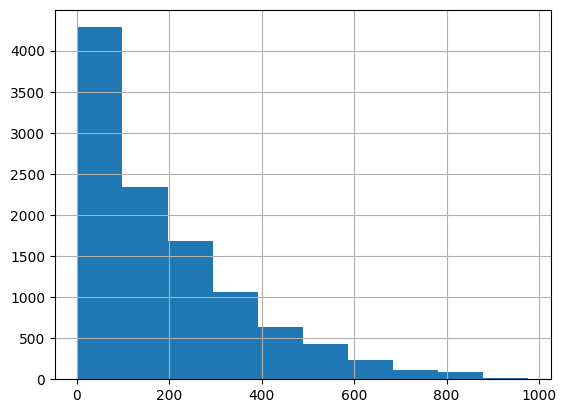

In [165]:
train['count'].hist()

In [181]:
# 전처리 
train['datetime'] = pd.to_datetime(train['datetime'])
test['datetime'] = pd.to_datetime(test['datetime'])

train['year'] = train['datetime'].dt.year
train['month'] = train['datetime'].dt.month
train['day'] = train['datetime'].dt.day 

test['year'] = test['datetime'].dt.year
test['month'] = test['datetime'].dt.month
test['day'] = test['datetime'].dt.day

# 역할을 다한 datetime 지우기
train = train.drop(['datetime'],axis=1)
test = test.drop(['datetime'],axis=1)

train = train.drop(['casual','registered'],axis=1)
display(train.head(2))

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,count,year,month,day
0,1,0,0,1,9.84,14.395,81,0.0,16,2011,1,1
1,1,0,0,1,9.02,13.635,80,0.0,40,2011,1,1


In [182]:
# target 별도 지정
target = train.pop('count')
print(target)

0         16
1         40
2         32
3         13
4          1
        ... 
10881    336
10882    241
10883    168
10884    129
10885     88
Name: count, Length: 10886, dtype: int64


In [183]:
X_train, X_test, y_train, y_test = train_test_split(train, target, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

# RandomForestRegressor

rf = RandomForestRegressor()
rf.fit(X_train, y_train)
pred = rf.predict(X_test)
print("Prediction : ",pred)

from sklearn.metrics import r2_score
print("R2 score : ",r2_score(y_test,pred))

(8708, 11) (2178, 11) (8708,) (2178,)
Prediction :  [217.52333333  33.61       143.72       ... 446.73        45.265
 214.54      ]
R2 score :  0.47010367442397694


In [184]:
# LinearRegressor
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train,y_train)
pred2 = lr.predict(X_test)
print("Prediction :",pred2)

print("R2 score : ",r2_score(y_test,pred))

Prediction : [260.4239056   76.93576534 152.41030381 ... 302.91736933  55.68260063
 239.67976676]
R2 score :  0.47010367442397694


In [186]:
# Xboost
from xgboost import XGBRegressor 

xgb = XGBRegressor()
xgb.fit(X_train,y_train)
pred3 = xgb.predict(X_test)
print("Prediction : ",pred3)

print("R2 score : ",r2_score(y_test,pred))

Prediction :  [383.37207  49.04112 117.40237 ... 431.1893   82.47809 222.77177]
R2 score :  0.47010367442397694
